### Support Vector Machines

SVM is performed on a clinical data set with patient demographics and tumor attributes. The label is the survival status of the patient.

#### Step 1: Data Prep

The raw data is not discrete so continous variables need to be descritized, and categorical variables need to be encoded with one hot encoding.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [58]:
## load data and examine head of data
import pandas as pd
filename = "cleaned_cgga_693_clinical.csv"
df = pd.read_csv(filename)
df.head()

,sample_id,tumor_type,tumor_histology,tumor_grade,gender,age,survival_days,survival_status,radio_status,chemo_status,mutation_status,codeletion_status
0,1002,P,anaplastic astrocyma,3,F,43.0,305.0,1.0,1.0,1.0,Wildtype,Non-codel
1,1003,P,oligodendroglioma,2,F,47.0,3817.0,0.0,0.0,1.0,Mutant,Codel
2,1010,P,astrocytoma,2,M,45.0,246.0,1.0,1.0,1.0,Mutant,Non-codel
3,1012,R,oligodendroglioma,2,M,45.0,3679.0,1.0,1.0,1.0,Mutant,Non-codel
4,1014,P,astrocytoma,2,M,42.0,263.0,1.0,0.0,1.0,Wildtype,Non-codel


In [59]:
# drop unnecessary or redundant columns
df = df.drop(columns=['sample_id','survival_days'])
df.head()

,tumor_type,tumor_histology,tumor_grade,gender,age,survival_status,radio_status,chemo_status,mutation_status,codeletion_status
0,P,anaplastic astrocyma,3,F,43.0,1.0,1.0,1.0,Wildtype,Non-codel
1,P,oligodendroglioma,2,F,47.0,0.0,0.0,1.0,Mutant,Codel
2,P,astrocytoma,2,M,45.0,1.0,1.0,1.0,Mutant,Non-codel
3,R,oligodendroglioma,2,M,45.0,1.0,1.0,1.0,Mutant,Non-codel
4,P,astrocytoma,2,M,42.0,1.0,0.0,1.0,Wildtype,Non-codel


In [60]:
# use one hot encoding to tranform catagorical feautures

from sklearn.preprocessing import OneHotEncoder

#  categorical columns to encode
categorical_cols = ['tumor_type', 'tumor_histology',
                    'gender','radio_status','chemo_status','mutation_status',
                    'codeletion_status']  

# fit encoder
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(df[categorical_cols])

# get the new column names
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# turn back into a DataFrame
encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols, index=df.index)

# drop original columns and join the new encoded ones
df = df.drop(columns=categorical_cols).join(encoded_df)
df.head()

/Users/julianazweng/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,tumor_grade,age,survival_status,tumor_type_P,tumor_type_R,tumor_histology_anaplastic astrocyma,tumor_histology_anaplastic oligoastrocytoma,tumor_histology_astrocytoma,tumor_histology_glioblastoma,tumor_histology_oligoastrocytoma,...,gender_F,gender_M,radio_status_0.0,radio_status_1.0,chemo_status_0.0,chemo_status_1.0,mutation_status_Mutant,mutation_status_Wildtype,codeletion_status_Codel,codeletion_status_Non-codel
0,3,43.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,2,47.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,2,45.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3,2,45.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
4,2,42.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


### Step 2: Split data into training and testing

In [61]:
## training and testing for SVM 

Training_SVM, Testing_SVM = train_test_split(df, test_size=.3)
##  Save the Labels and then remove them from the Training and Testing data
Training_SVM_Label = Training_SVM["survival_status"]
Training_SVM=Training_SVM.drop(["survival_status"], axis=1)
Testing_SVM_Label = Testing_SVM["survival_status"]
Testing_SVM=Testing_SVM.drop(["survival_status"], axis=1)
print("Testing SVM:", Testing_SVM)
print("Testing SVM labels:", Testing_SVM_Label)
## -------------------------------------------------------------

Testing SVM:      tumor_grade   age  tumor_type_P  tumor_type_R  \
47             2  41.0           1.0           0.0   
384            4  45.0           0.0           1.0   
278            4  57.0           0.0           1.0   
346            3  49.0           1.0           0.0   
427            2  25.0           1.0           0.0   
..           ...   ...           ...           ...   
305            3  45.0           1.0           0.0   
126            4  62.0           1.0           0.0   
27             4  35.0           1.0           0.0   
452            3  42.0           0.0           1.0   
589            2  27.0           0.0           1.0   

     tumor_histology_anaplastic astrocyma  \
47                                    0.0   
384                                   0.0   
278                                   0.0   
346                                   1.0   
427                                   0.0   
..                                    ...   
305                    

#### SVM #1.1 : Polynomial, Degree 3, Cost 1.0

In [62]:
from sklearn.svm import SVC

SVM 1 prediction:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Actual:
[[  0  72]
 [  0 113]]

Accuracy: 0.6108


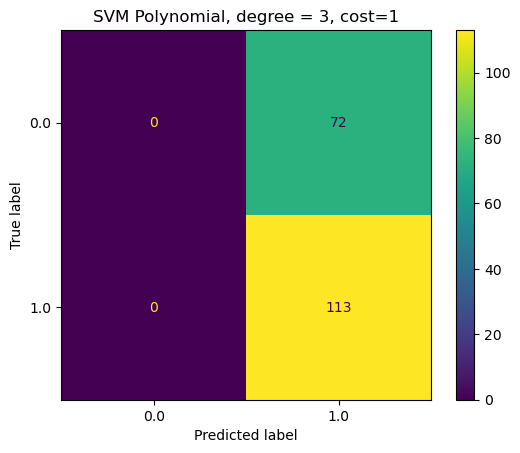

In [63]:
SVM_Model1=SVC(C=1.0, kernel='poly', degree=3)
SVM_Model1.fit(Training_SVM, Training_SVM_Label)

print("SVM 1 prediction:\n", SVM_Model1.predict(Testing_SVM))
print("Actual:")
#print(Testing_SVM_Label)

SVM_matrix_poly = confusion_matrix(Testing_SVM_Label, SVM_Model1.predict(Testing_SVM))

print(SVM_matrix_poly)


# print accuracy
accuracy = accuracy_score(Testing_SVM_Label, SVM_Model1.predict(Testing_SVM))
print(f"\nAccuracy: {accuracy:.4f}")

## pretty Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_poly,display_labels=SVM_Model1.classes_)
disp.plot()
plt.title("SVM Polynomial, degree = 3, cost=1")
plt.show()


#### SVM #1.2 : Polynomial, Degree 3, Cost 10

SVM 1.2 prediction:
 [0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0.
 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Actual:
[[ 38  34]
 [ 12 101]]




Accuracy: 0.7514


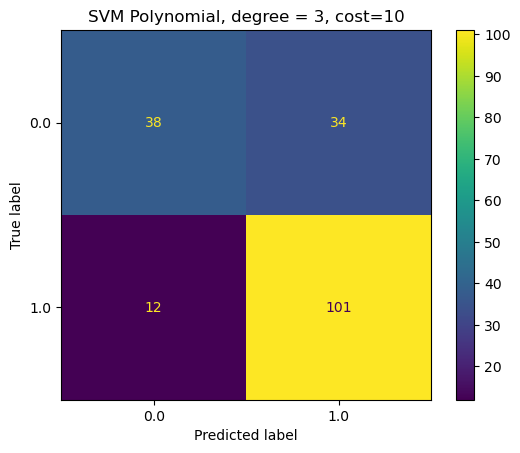

In [64]:
SVM_Model1_2=SVC(C=10, kernel='poly', degree=3)
SVM_Model1_2.fit(Training_SVM, Training_SVM_Label)

print("SVM 1.2 prediction:\n", SVM_Model1_2.predict(Testing_SVM))
print("Actual:")
#print(Testing_SVM_Label)

SVM_matrix_poly_2 = confusion_matrix(Testing_SVM_Label, SVM_Model1_2.predict(Testing_SVM))

print(SVM_matrix_poly_2)
print("\n\n")

# print accuracy
accuracy = accuracy_score(Testing_SVM_Label, SVM_Model1_2.predict(Testing_SVM))
print(f"\nAccuracy: {accuracy:.4f}")

## pretty Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_poly_2,display_labels=SVM_Model1.classes_)
disp.plot()
plt.title("SVM Polynomial, degree = 3, cost=10")
plt.show()

#### SVM #1.3 : Polynomial, Degree 3, Cost 100

[[54 18]
 [22 91]]

Accuracy: 0.7838


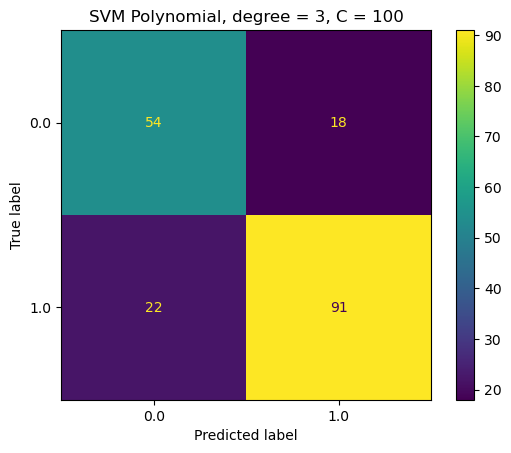

In [65]:
SVM_Model1_3 = SVC(C=100, kernel='poly', degree=3)
SVM_Model1_3.fit(Training_SVM, Training_SVM_Label)

# Make predictions
predictions_1_3 = SVM_Model1_3.predict(Testing_SVM)


SVM_matrix_poly_3 = confusion_matrix(Testing_SVM_Label, predictions_1_3)
print(SVM_matrix_poly_3)

# Print accuracy
accuracy_1_3 = accuracy_score(Testing_SVM_Label, predictions_1_3)
print(f"\nAccuracy: {accuracy_1_3:.4f}")

# Pretty confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_poly_3, display_labels=SVM_Model1_3.classes_)
disp.plot()
plt.title("SVM Polynomial, degree = 3, C = 100")
plt.show()

#### SVM #2 : RBF, Cost 1.0

SVM 2 prediction:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Actual:

The confusion matrix for Linear SVM is:
[[  0  72]
 [  0 113]]




Accuracy: 0.6108


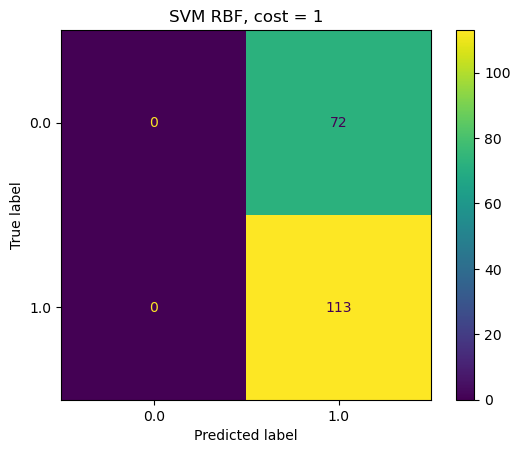

In [66]:
## RBF
SVM_Model2=SVC(C=1, kernel='rbf')

SVM_Model2.fit(Training_SVM, Training_SVM_Label)

print("SVM 2 prediction:\n", SVM_Model2.predict(Testing_SVM))
print("Actual:")
#print(Testing_SVM_Label)

SVM_matrix_rbf = confusion_matrix(Testing_SVM_Label, SVM_Model2.predict(Testing_SVM))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix_rbf)
print("\n\n")

# print accuracy
accuracy = accuracy_score(Testing_SVM_Label, SVM_Model2.predict(Testing_SVM))
print(f"\nAccuracy: {accuracy:.4f}")

## pretty Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_rbf,display_labels=SVM_Model2.classes_)
disp.plot()
plt.title("SVM RBF, cost = 1")
plt.show()

#### SVM #2.2 : RBF, Cost 10

SVM 2.2 prediction:
 [0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0.
 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0.]
Actual:

The confusion matrix for Linear SVM is:
[[56 16]
 [19 94]]




Accuracy: 0.8108


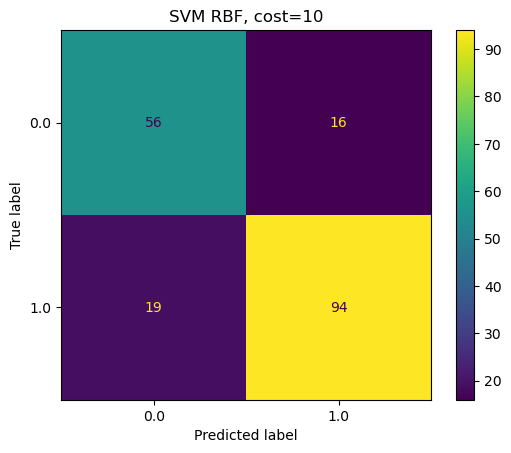

In [67]:
## RBF
SVM_Model2_2=SVC(C=10, kernel='rbf')

SVM_Model2_2.fit(Training_SVM, Training_SVM_Label)

print("SVM 2.2 prediction:\n", SVM_Model2_2.predict(Testing_SVM))
print("Actual:")
#print(Testing_SVM_Label)

SVM_matrix_rbf_2 = confusion_matrix(Testing_SVM_Label, SVM_Model2_2.predict(Testing_SVM))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix_rbf_2)
print("\n\n")

# print accuracy
accuracy = accuracy_score(Testing_SVM_Label, SVM_Model2_2.predict(Testing_SVM))
print(f"\nAccuracy: {accuracy:.4f}")

## pretty Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_rbf_2,display_labels=SVM_Model2_2.classes_)
disp.plot()
plt.title("SVM RBF, cost=10")
plt.show()

#### SVM #2.3 : RBF, Cost .1


SVM 2.3 prediction:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Actual:

The confusion matrix for Linear SVM is:
[[  0  72]
 [  0 113]]




Accuracy: 0.6108


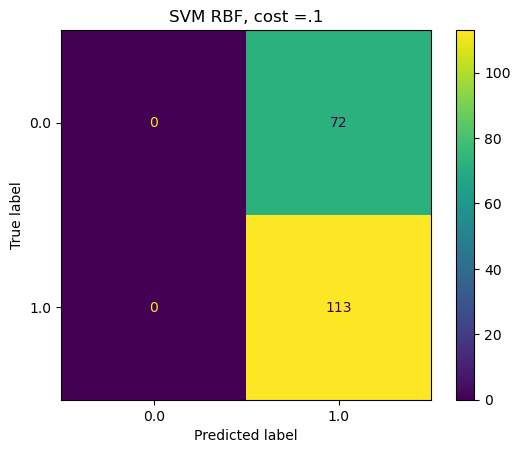

In [68]:
## RBF
SVM_Model2_3=SVC(C=.1, kernel='rbf')

SVM_Model2_3.fit(Training_SVM, Training_SVM_Label)

print("SVM 2.3 prediction:\n", SVM_Model2_3.predict(Testing_SVM))
print("Actual:")
#print(Testing_SVM_Label)

SVM_matrix_rbf_3 = confusion_matrix(Testing_SVM_Label, SVM_Model2_3.predict(Testing_SVM))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix_rbf_3)
print("\n\n")

# print accuracy
accuracy = accuracy_score(Testing_SVM_Label, SVM_Model2_3.predict(Testing_SVM))
print(f"\nAccuracy: {accuracy:.4f}")

## pretty Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_rbf_3,display_labels=SVM_Model2_3.classes_)
disp.plot()
plt.title("SVM RBF, cost =.1")
plt.show()


#### SVM #3.1: Linear, Cost 10

SVM 3 prediction:
 [0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0.]
Actual:

The confusion matrix for Linear SVM is:
[[50 22]
 [19 94]]




Accuracy: 0.7784


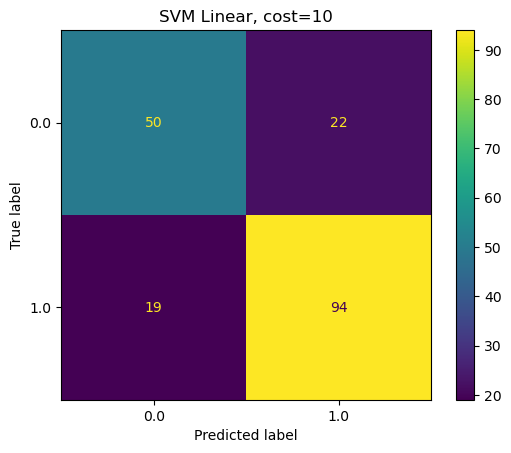

In [69]:
## linear
SVM_Model3=SVC(C=10, kernel='linear')

SVM_Model3.fit(Training_SVM, Training_SVM_Label)

print("SVM 3 prediction:\n", SVM_Model3.predict(Testing_SVM))
print("Actual:")
#print(Testing_SVM_Label)

SVM_matrix_linear = confusion_matrix(Testing_SVM_Label, SVM_Model3.predict(Testing_SVM))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix_linear)
print("\n\n")

# print accuracy
accuracy = accuracy_score(Testing_SVM_Label, SVM_Model3.predict(Testing_SVM))
print(f"\nAccuracy: {accuracy:.4f}")

## pretty Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_linear,display_labels=SVM_Model3.classes_)
disp.plot()
plt.title("SVM Linear, cost=10")
plt.show()

#### SVM #3.2 : Linear, Cost 1

SVM 3.2 prediction:
 [0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0.]
Actual:

The confusion matrix for Linear SVM is:
[[50 22]
 [19 94]]




Accuracy: 0.7784


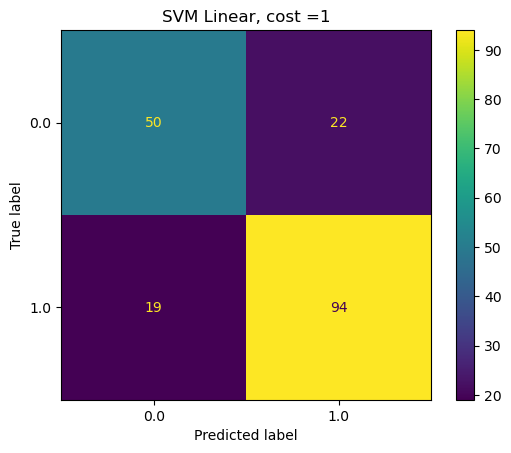

In [70]:
## linear
SVM_Model3_2=SVC(C=1, kernel='linear')

SVM_Model3_2.fit(Training_SVM, Training_SVM_Label)

print("SVM 3.2 prediction:\n", SVM_Model3_2.predict(Testing_SVM))
print("Actual:")
#print(Testing_SVM_Label)

SVM_matrix_linear_2 = confusion_matrix(Testing_SVM_Label, SVM_Model3_2.predict(Testing_SVM))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix_linear_2)
print("\n\n")

# print accuracy
accuracy = accuracy_score(Testing_SVM_Label, SVM_Model3_2.predict(Testing_SVM))
print(f"\nAccuracy: {accuracy:.4f}")

## pretty Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_linear_2,display_labels=SVM_Model3_2.classes_)
disp.plot()
plt.title("SVM Linear, cost =1")
plt.show()


#### SVM #3.3 : Linear, Cost .1

SVM 3.3 prediction:
 [0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0.]
Actual:

The confusion matrix for Linear SVM is:
[[52 20]
 [20 93]]




Accuracy: 0.7838


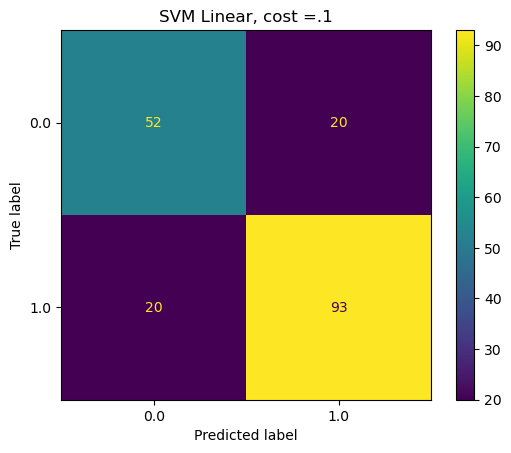

In [71]:
## linear
SVM_Model3_3=SVC(C=0.1, kernel='linear')

SVM_Model3_3.fit(Training_SVM, Training_SVM_Label)

print("SVM 3.3 prediction:\n", SVM_Model3_3.predict(Testing_SVM))
print("Actual:")
#print(Testing_SVM_Label)

SVM_matrix_linear_3 = confusion_matrix(Testing_SVM_Label, SVM_Model3_3.predict(Testing_SVM))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix_linear_3)
print("\n\n")

# print accuracy
accuracy = accuracy_score(Testing_SVM_Label, SVM_Model3_3.predict(Testing_SVM))
print(f"\nAccuracy: {accuracy:.4f}")

## pretty Confusion Matrix

disp = ConfusionMatrixDisplay(confusion_matrix=SVM_matrix_linear_3,display_labels=SVM_Model3_3.classes_)
disp.plot()
plt.title("SVM Linear, cost =.1")
plt.show()


#### Visualze best SVM from each kernel

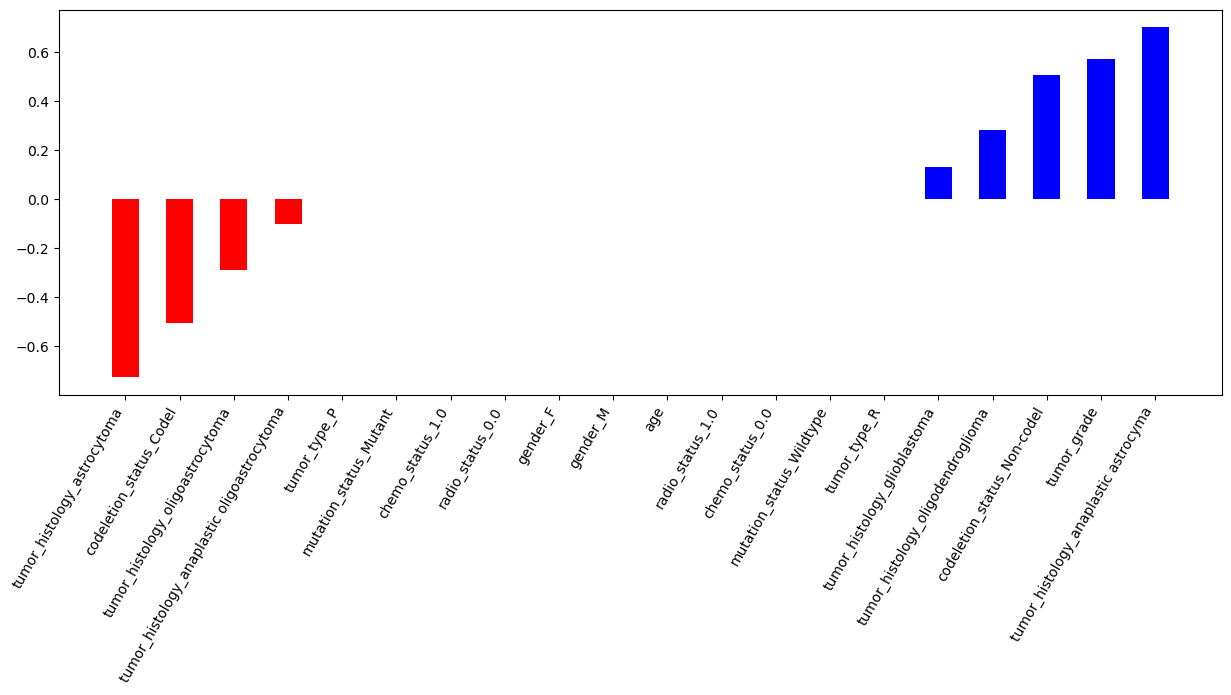

In [73]:
###################################################
##
##   Visualizing the top features
##   Then Visualizing the margin with the top 2 in 2D
##
##########################################################

import matplotlib.pyplot as plt
## Credit: https://medium.com/@aneesha/visualising-top-features-in-linear-svm-with-scikit-learn-and-matplotlib-3454ab18a14d
## Define a function to visualize the TOP words (variables)
def plot_coefficients(MODEL=SVM_Model3_3, COLNAMES=Training_SVM.columns, top_features=10):
    ## Model if SVM MUST be SVC, RE: SVM_Model=LinearSVC(C=10)
    coef = MODEL.coef_.ravel()
    top_positive_coefficients = np.argsort(coef,axis=0)[-top_features:]
    top_negative_coefficients = np.argsort(coef,axis=0)[:top_features]
    top_coefficients = np.hstack([top_negative_coefficients, top_positive_coefficients])
    # create plot
    plt.figure(figsize=(15, 5))
    colors = ["red" if c < 0 else "blue" for c in coef[top_coefficients]]
    plt.bar(  x=  np.arange(2 * top_features)  , height=coef[top_coefficients], width=.5,  color=colors)
    feature_names = np.array(COLNAMES)
    plt.xticks(np.arange(0, (2*top_features)), feature_names[top_coefficients], rotation=60, ha="right")
    plt.show()
    

plot_coefficients()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[[32.  2.]
 [40.  2.]
 [55.  2.]
 [39.  4.]
 [43.  3.]
 [30.  3.]
 [49.  4.]
 [46.  3.]
 [53.  3.]
 [38.  3.]
 [35.  3.]
 [53.  4.]
 [46.  4.]
 [46.  4.]
 [33.  2.]
 [46.  2.]
 [37.  3.]
 [50.  3.]
 [47.  3.]
 [29.  4.]
 [31.  2.]
 [61.  3.]
 [47.  4.]
 [33.  3.]
 [59.  3.]
 [31.  3.]
 [55.  4.]
 [64.  4.]
 [48.  2.]
 [43.  3.]
 [68.  4.]
 [24.  3.]
 [55.  3.]
 [38.  3.]
 [63.  4.]
 [48.  2.]
 [51.  3.]
 [37.  3.]
 [41.  4.]
 [51.  4.]
 [47.  3.]
 [43.  2.]
 [61.  3.]
 [22.  4.]
 [43.  4.]
 [29.  3.]
 [52.  2.]
 [41.  4.]
 [50.  3.]
 [43.  3.]
 [20.  3.]
 [48.  3.]
 [33.  3.]
 [49.  3.]
 [36.  2.]
 [39.  3.]
 [34.  2.]
 [61.  4.]
 [46.  3.]
 [36.  2.]
 [41.  2.]
 [50.  4.]
 [58.  3.]
 [54.  3.]
 [42.  4.]
 [39.  3.]
 [43.  3.]
 [36.  2.]
 [56.  3.]
 [41.  4.]
 [32.  2.]
 [28.  4.]
 [45.  2.]
 [42.  2.]
 [40.  3.]
 [25.  2.]
 [58.  4.]
 [35.  2.]
 [48.  3.]
 [51.  2.]
 [60.  4.]
 [23.  2.]
 [45.  3.]
 [33.  3.]
 [52.  4.]
 [72.  4.]
 [61.  4.]
 [60.  4.]
 [39.  3.]
 [39.  3.]
 [38.  4.]

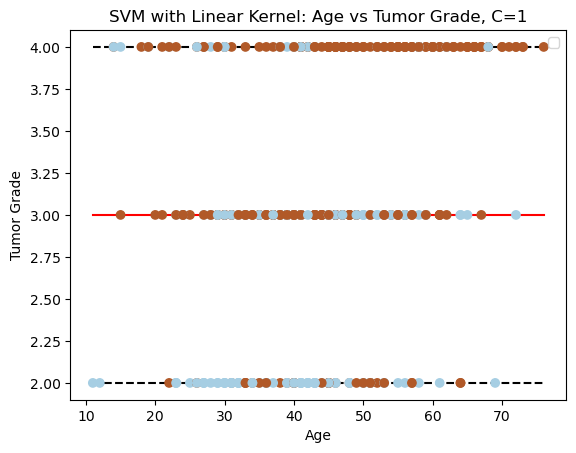

In [101]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn import preprocessing

# Replace TRAIN and TRAIN_Labels with your actual dataset and labels
# Assuming 'age' and 'tumor_grade' are the columns you want to use
X = np.array([Training_SVM["age"], Training_SVM["tumor_grade"]])
X = X.transpose()  # Ensure the data is in the correct shape for SVM
print(X)

# Assuming TRAIN_Labels is your target labels
y = Training_SVM_Label
print(y)

# Binarize the labels for classification
lb = preprocessing.LabelBinarizer()
y = lb.fit_transform(y)
y = np.array(y)
y = y.ravel()  # Flatten the array to make it 1D for SVM

print(y)

# Define the SVM model with a linear kernel and fit it to the data
clf = SVC(C=1, kernel="linear")
clf.fit(X, y)

# Calculate the margin
margin = 2 / np.sqrt(np.sum(clf.coef_ ** 2))

# Get the separating hyperplane (SVM weights)
w = clf.coef_[0]

# The slope of the separating line (hyperplane)
a = -w[0] / w[1]

# Create a variable for x values (age)
xx = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 100)

# Equation of the separating line
yy = a * xx - (clf.intercept_[0]) / w[1]

# Create the margin lines
yy_down = yy + 0.5 * margin
yy_up = yy - 0.5 * margin

# Plot the results
plt.clf()
plt.plot(xx, yy, 'r-')  # Red separating line
plt.plot(xx, yy_down, 'k--')  # Black dashed lower margin
plt.plot(xx, yy_up, 'k--')  # Black dashed upper margin

# Plot the support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=10, 
            facecolors='none', edgecolors='k', zorder=5)

# Scatter plot of the data points (colored by class)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, zorder=5)

# Set axis labels and title
plt.xlabel('Age')
plt.ylabel('Tumor Grade')
plt.title('SVM with Linear Kernel: Age vs Tumor Grade, C=1')

# Add a legend
plt.legend()

# Display the plot
plt.axis('tight')
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[[1. 2.]
 [1. 2.]
 [0. 2.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [0. 4.]
 [0. 4.]
 [1. 2.]
 [1. 2.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [0. 2.]
 [0. 3.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [0. 4.]
 [1. 2.]
 [0. 3.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [1. 2.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [0. 4.]
 [0. 3.]
 [1. 2.]
 [0. 3.]
 [0. 4.]
 [0. 4.]
 [0. 3.]
 [1. 2.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [1. 2.]
 [0. 3.]
 [1. 2.]
 [0. 4.]
 [0. 3.]
 [0. 2.]
 [1. 2.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [0. 2.]
 [0. 3.]
 [0. 4.]
 [0. 2.]
 [0. 4.]
 [0. 2.]
 [0. 2.]
 [0. 3.]
 [1. 2.]
 [0. 4.]
 [1. 2.]
 [0. 3.]
 [1. 2.]
 [0. 4.]
 [1. 2.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [0. 4.]
 [0. 4.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [1. 2.]
 [0. 4.]
 [0. 3.]
 [0. 3.]
 [1. 2.]
 [1. 2.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [1. 2.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 3.]
 [0. 4.]
 [0. 3.]
 [0. 4.]
 [0. 3.]
 [0. 2.]
 [1. 2.]
 

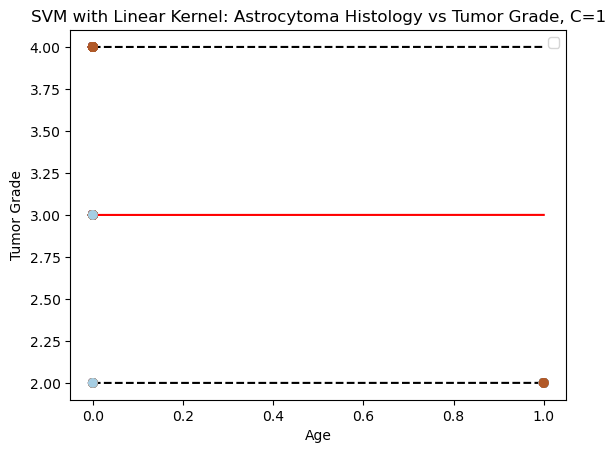

In [100]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn import preprocessing

# Replace TRAIN and TRAIN_Labels with your actual dataset and labels
# Assuming 'age' and 'tumor_grade' are the columns you want to use
X = np.array([Training_SVM["tumor_histology_astrocytoma"], Training_SVM["tumor_grade"]])
X = X.transpose()  # Ensure the data is in the correct shape for SVM
print(X)

# Assuming TRAIN_Labels is your target labels
y = Training_SVM_Label
print(y)

# Binarize the labels for classification
lb = preprocessing.LabelBinarizer()
y = lb.fit_transform(y)
y = np.array(y)
y = y.ravel()  # Flatten the array to make it 1D for SVM

print(y)

# Define the SVM model with a linear kernel and fit it to the data
clf = SVC(C=10, kernel="linear")
clf.fit(X, y)

# Calculate the margin
margin = 2 / np.sqrt(np.sum(clf.coef_ ** 2))

# Get the separating hyperplane (SVM weights)
w = clf.coef_[0]

# The slope of the separating line (hyperplane)
a = -w[0] / w[1]

# Create a variable for x values (age)
xx = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 100)

# Equation of the separating line
yy = a * xx - (clf.intercept_[0]) / w[1]

# Create the margin lines
yy_down = yy + 0.5 * margin
yy_up = yy - 0.5 * margin

# Plot the results
plt.clf()
plt.plot(xx, yy, 'r-')  # Red separating line
plt.plot(xx, yy_down, 'k--')  # Black dashed lower margin
plt.plot(xx, yy_up, 'k--')  # Black dashed upper margin

# Plot the support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=10, 
            facecolors='none', edgecolors='k', zorder=5)

# Scatter plot of the data points (colored by class)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, zorder=5)

# Set axis labels and title
plt.xlabel('Age')
plt.ylabel('Tumor Grade')
plt.title('SVM with Linear Kernel: Astrocytoma Histology vs Tumor Grade, C=1')

# Add a legend
plt.legend()

# Display the plot
plt.axis('tight')
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[[32.  0.]
 [40.  0.]
 [55.  1.]
 [39.  1.]
 [43.  1.]
 [30.  0.]
 [49.  0.]
 [46.  0.]
 [53.  1.]
 [38.  1.]
 [35.  1.]
 [53.  0.]
 [46.  0.]
 [46.  0.]
 [33.  0.]
 [46.  0.]
 [37.  0.]
 [50.  1.]
 [47.  1.]
 [29.  0.]
 [31.  1.]
 [61.  0.]
 [47.  0.]
 [33.  0.]
 [59.  0.]
 [31.  0.]
 [55.  0.]
 [64.  0.]
 [48.  0.]
 [43.  0.]
 [68.  0.]
 [24.  1.]
 [55.  0.]
 [38.  0.]
 [63.  0.]
 [48.  0.]
 [51.  0.]
 [37.  1.]
 [41.  0.]
 [51.  0.]
 [47.  0.]
 [43.  0.]
 [61.  0.]
 [22.  0.]
 [43.  0.]
 [29.  1.]
 [52.  0.]
 [41.  0.]
 [50.  0.]
 [43.  0.]
 [20.  0.]
 [48.  0.]
 [33.  1.]
 [49.  1.]
 [36.  0.]
 [39.  1.]
 [34.  0.]
 [61.  0.]
 [46.  0.]
 [36.  1.]
 [41.  0.]
 [50.  0.]
 [58.  1.]
 [54.  0.]
 [42.  1.]
 [39.  0.]
 [43.  1.]
 [36.  1.]
 [56.  0.]
 [41.  0.]
 [32.  1.]
 [28.  0.]
 [45.  0.]
 [42.  1.]
 [40.  0.]
 [25.  0.]
 [58.  0.]
 [35.  1.]
 [48.  0.]
 [51.  0.]
 [60.  0.]
 [23.  0.]
 [45.  0.]
 [33.  1.]
 [52.  0.]
 [72.  0.]
 [61.  0.]
 [60.  0.]
 [39.  1.]
 [39.  0.]
 [38.  0.]

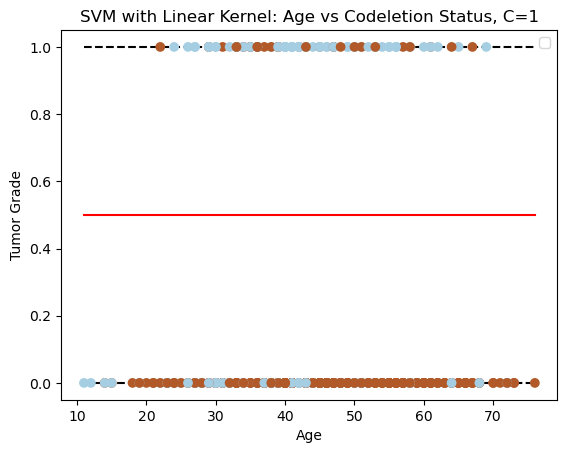

In [99]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn import preprocessing

# Replace TRAIN and TRAIN_Labels with your actual dataset and labels
# Assuming 'age' and 'tumor_grade' are the columns you want to use
X = np.array([Training_SVM["age"], Training_SVM["codeletion_status_Codel"]])
X = X.transpose()  # Ensure the data is in the correct shape for SVM
print(X)

# Assuming TRAIN_Labels is your target labels
y = Training_SVM_Label
print(y)

# Binarize the labels for classification
lb = preprocessing.LabelBinarizer()
y = lb.fit_transform(y)
y = np.array(y)
y = y.ravel()  # Flatten the array to make it 1D for SVM

print(y)

# Define the SVM model with a linear kernel and fit it to the data
clf = SVC(C=1, kernel="linear")
clf.fit(X, y)

# Calculate the margin
margin = 2 / np.sqrt(np.sum(clf.coef_ ** 2))

# Get the separating hyperplane (SVM weights)
w = clf.coef_[0]

# The slope of the separating line (hyperplane)
a = -w[0] / w[1]

# Create a variable for x values (age)
xx = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 100)

# Equation of the separating line
yy = a * xx - (clf.intercept_[0]) / w[1]

# Create the margin lines
yy_down = yy + 0.5 * margin
yy_up = yy - 0.5 * margin

# Plot the results
plt.clf()
plt.plot(xx, yy, 'r-')  # Red separating line
plt.plot(xx, yy_down, 'k--')  # Black dashed lower margin
plt.plot(xx, yy_up, 'k--')  # Black dashed upper margin

# Plot the support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=10, 
            facecolors='none', edgecolors='k', zorder=5)

# Scatter plot of the data points (colored by class)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, zorder=5)

# Set axis labels and title
plt.xlabel('Age')
plt.ylabel('Tumor Grade')
plt.title('SVM with Linear Kernel: Age vs Codeletion Status, C=1')

# Add a legend
plt.legend()

# Display the plot
plt.axis('tight')
plt.show()
